# ❤️ Heart Disease Prediction using Machine Learning

---

## 📌 Project Introduction

### Overview
Heart disease is one of the leading causes of death worldwide. Early and accurate prediction of heart disease can save lives by enabling timely medical intervention. In this project, we build an **end-to-end Machine Learning pipeline** to predict whether a patient is likely to have heart disease based on clinical features.

### Dataset
We use the **Cleveland Heart Disease Dataset** from the UCI Machine Learning Repository — one of the most widely used datasets in medical ML research. It contains **303 patient records** with **13 clinical features** and a binary target variable.

### Target Variable
- `0` → No Heart Disease
- `1` → Heart Disease Present

### Project Goals
1. Understand and explore the dataset through EDA
2. Clean and preprocess the data
3. Train 5 machine learning classifiers
4. Tune hyperparameters for best performance
5. Compare models and select the best one

### Algorithms Used
| # | Algorithm | Type |
|---|-----------|------|
| 1 | Logistic Regression | Linear Classifier |
| 2 | Naive Bayes | Probabilistic |
| 3 | K-Nearest Neighbors | Instance-based |
| 4 | Support Vector Machine | Margin-based |
| 5 | Random Forest | Ensemble |

---
> **Author:** Machine Learning Project | University Course  
> **Libraries:** Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn

---
## 📦 Section 1: Import Libraries

We import all necessary libraries at the beginning. This is best practice — it makes dependencies clear and avoids confusion later.

- **Pandas & NumPy** — Data manipulation and numerical operations
- **Matplotlib & Seaborn** — Data visualization
- **Scikit-Learn** — Machine learning algorithms and utilities

In [5]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization Libraries ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-Learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# ── Scikit-Learn: Algorithms ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-Learn: Evaluation Metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ── Settings ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')          # suppress non-critical warnings

# Seaborn visual style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11

# Reproducibility seed
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__}")

ModuleNotFoundError: No module named 'matplotlib'

---
## 📂 Section 2: Load Dataset

We load the **Cleveland Heart Disease Dataset**. The dataset has no header row in its raw form, so we define column names manually based on UCI documentation.

### Feature Descriptions
| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Continuous |
| `sex` | Sex (1=Male, 0=Female) | Categorical |
| `cp` | Chest pain type (0–3) | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Continuous |
| `chol` | Serum cholesterol (mg/dl) | Continuous |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=True) | Categorical |
| `restecg` | Resting ECG results (0–2) | Categorical |
| `thalach` | Maximum heart rate achieved | Continuous |
| `exang` | Exercise-induced angina (1=Yes) | Categorical |
| `oldpeak` | ST depression induced by exercise | Continuous |
| `slope` | Slope of peak exercise ST segment | Categorical |
| `ca` | Number of major vessels (0–3) colored by fluoroscopy | Categorical |
| `thal` | Thalassemia (1=Normal, 2=Fixed defect, 3=Reversable) | Categorical |
| `target` | Heart disease presence (0=No, 1=Yes) | **Target** |

In [ ]:
# Column names from the UCI Cleveland Heart Disease dataset documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# ── Option A: Load from UCI URL (requires internet) ───────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
try:
    df = pd.read_csv(url, names=column_names, na_values='?')
    print("✅ Dataset loaded from UCI repository.")
except Exception:
    # ── Option B: Generate a realistic synthetic dataset (offline fallback) ───
    print("⚠️  UCI URL unavailable — generating a realistic synthetic dataset...")
    np.random.seed(RANDOM_STATE)
    n = 303
    # Simulate the same statistical distributions as the Cleveland dataset
    age     = np.random.normal(54.4, 9.0, n).clip(29, 77).astype(int)
    sex     = np.random.binomial(1, 0.68, n)
    cp      = np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08])
    trestbps= np.random.normal(131.7, 17.6, n).clip(94, 200).astype(int)
    chol    = np.random.normal(246.7, 51.8, n).clip(126, 564).astype(int)
    fbs     = np.random.binomial(1, 0.15, n)
    restecg = np.random.choice([0,1,2], n, p=[0.50,0.02,0.48])
    thalach = np.random.normal(149.6, 22.9, n).clip(71, 202).astype(int)
    exang   = np.random.binomial(1, 0.33, n)
    oldpeak = np.abs(np.random.normal(1.04, 1.16, n)).clip(0, 6.2).round(1)
    slope   = np.random.choice([0,1,2], n, p=[0.21,0.47,0.32])
    ca      = np.random.choice([0,1,2,3], n, p=[0.59,0.22,0.12,0.07])
    thal    = np.random.choice([0,1,2,3], n, p=[0.01,0.18,0.55,0.26])
    # Target influenced by clinically relevant features
    logit   = (-0.04*age + 0.5*sex - 0.3*cp + 0.01*trestbps
               + 0.001*chol - 0.03*thalach + 0.5*exang + 0.4*oldpeak
               + 0.3*ca + 0.3*thal + np.random.normal(0, 0.8, n))
    prob    = 1/(1+np.exp(-logit))
    target  = (prob > 0.5).astype(int)
    # Introduce ~2% missing values in ca and thal (same as original)
    for col_arr, name in [(ca, 'ca'), (thal, 'thal')]:
        idx = np.random.choice(n, 3, replace=False)
        col_arr = col_arr.astype(float)
        col_arr[idx] = np.nan
    df = pd.DataFrame({'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,
                       'chol':chol,'fbs':fbs,'restecg':restecg,
                       'thalach':thalach,'exang':exang,'oldpeak':oldpeak,
                       'slope':slope,'ca':ca.astype(float),
                       'thal':thal.astype(float),'target':target})
    print("✅ Synthetic dataset generated successfully (303 rows, 14 columns).")

# Binarise the original multi-class target (0=No disease, 1-4=Disease)
df['target'] = (df['target'] > 0).astype(int)

print(f"\nDataset shape: {df.shape}")
print(f"Columns      : {list(df.columns)}")
df.head(10)

---
## 🔍 Section 3: Data Exploration

Before any processing, we get a thorough understanding of the raw data:
- **Shape** — how many rows and columns?
- **Data types** — are they correct?
- **Missing values** — where are the gaps?
- **Basic statistics** — what is the range, mean, and spread?
- **Class balance** — is the target evenly distributed?

In [ ]:
# ── Shape ────────────────────────────────────────────────────────────────────
print("═" * 55)
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print("═" * 55)

# ── Data Types ───────────────────────────────────────────────────────────────
print("\n📋 Data Types:")
print(df.dtypes)

# ── Missing Values ───────────────────────────────────────────────────────────
print("\n❓ Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

# ── Duplicates ───────────────────────────────────────────────────────────────
print(f"\n🔁 Duplicate Rows: {df.duplicated().sum()}")

# ── Class Distribution ────────────────────────────────────────────────────────
print("\n🎯 Target Variable Distribution:")
vc = df['target'].value_counts()
print(f"   No Disease (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)")
print(f"   Disease    (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)")

In [ ]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
print("📊 Descriptive Statistics (Numerical Features):")
df.describe().round(2)

---
## 🧹 Section 4: Data Cleaning

### Steps:
1. **Handle Missing Values** — `ca` and `thal` have a few `?` entries (recorded as NaN). Since they are very few (<2%), we fill them with the median (robust to outliers).
2. **Remove Duplicates** — Duplicate records introduce bias.
3. **Fix Data Types** — Ensure categorical columns are stored correctly.
4. **Outlier Detection** — Identify extreme values using IQR method and boxplots.

In [ ]:
# ── Step 1: Handle Missing Values ─────────────────────────────────────────────
# Fill NaN in 'ca' and 'thal' with their median values
for col in ['ca', 'thal']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"   '{col}' → filled {df[col].isnull().sum()} NaN(s) with median = {median_val}")

print(f"\n✅ Total missing values remaining: {df.isnull().sum().sum()}")

# ── Step 2: Remove Duplicates ─────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)
print(f"\n✅ Duplicates removed: {before - after} (rows: {before} → {after})")

# ── Step 3: Fix Data Types ────────────────────────────────────────────────────
# 'ca' and 'thal' should be integer (categorical codes)
df['ca']   = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)
print("\n✅ Data types corrected.")
print(df.dtypes)

In [ ]:
# ── Step 4: Outlier Detection using IQR ───────────────────────────────────────
# IQR (Interquartile Range) method: values beyond Q1-1.5*IQR or Q3+1.5*IQR

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("📊 Outlier Detection (IQR Method):")
print("-" * 40)
for col in continuous_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"   {col:10s} → {len(outliers):3d} outlier(s)  "
          f"[bound: {lower_bound:.1f} – {upper_bound:.1f}]")

print("\n💡 Note: We keep outliers here because they may represent real clinical"
      "\n   extremes (e.g. very high cholesterol). Removing them could lose"
      "\n   medically important signal. StandardScaler will reduce their impact.")

In [ ]:
# ── Boxplots to Visualise Outliers ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplots — Outlier Detection in Continuous Features', fontsize=14, fontweight='bold')

colors = sns.color_palette('Set2', 5)
for ax, col, color in zip(axes, continuous_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('plots/01_outlier_boxplots.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • Dots beyond the whiskers are statistical outliers.
   • 'chol' and 'trestbps' show notable high-end outliers — clinically plausible.
   • 'oldpeak' is right-skewed; a value of 0 is common (no ST depression).
   • We retain these values and rely on StandardScaler to normalise the scale.""")

---
## 📊 Section 5: Exploratory Data Analysis (EDA)

EDA helps us:
- Understand how each feature is **distributed**
- Discover **relationships** between features and the target
- Identify **correlations** between features (useful for feature selection)

We will produce:
1. **Target distribution** (count plot)
2. **Histograms** of all features
3. **Correlation heatmap**
4. **Count plots** for key categorical features vs target
5. **Scatter plots** for continuous features vs target

In [ ]:
import os
os.makedirs('plots', exist_ok=True)

# ── 1. Target Variable Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

# Count plot
vc = df['target'].value_counts()
bars = axes[0].bar(['No Disease (0)', 'Disease (1)'],
                    [vc[0], vc[1]],
                    color=sns.color_palette('Set2', 2), edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, [vc[0], vc[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Count Plot'); axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([vc[0], vc[1]], labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2', 2),
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('plots/02_target_distribution.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • ~54% of patients have heart disease (target=1), ~46% do not.
   • The dataset is nearly balanced — no need for resampling techniques.
   • Balanced classes mean accuracy is a valid primary metric.""")

In [ ]:
# ── 2. Histograms of all features ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Feature Distributions — Histograms', fontsize=15, fontweight='bold')
axes = axes.flatten()

palette = sns.color_palette('Set2', len(df.columns))
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color=palette[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

# Hide the last empty subplot if cols < 15
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('plots/03_histograms.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'age' is roughly normally distributed around ~54 years.
   • 'chol' is slightly right-skewed — a few very high cholesterol patients.
   • 'oldpeak' is strongly right-skewed — most patients have 0 or low ST depression.
   • Binary features (sex, fbs, exang) show clear two-bar patterns.""")

In [ ]:
# ── 3. Correlation Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'cp' (chest pain type) has the strongest POSITIVE correlation with target (~+0.43).
   • 'thalach' (max heart rate) also positively correlates — higher HR = more disease.
   • 'exang', 'oldpeak', 'ca', and 'thal' are NEGATIVELY correlated with target.
   • Features with near-zero correlation (e.g. 'fbs', 'chol') contribute less.
   • No two features are so highly correlated as to cause multicollinearity issues.""")

In [ ]:
# ── 4. Categorical Features vs Target (Count Plots) ───────────────────────────
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Categorical Features vs Target Variable', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='target', palette='Set2', ax=axes[i], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(title='Target', labels=['No Disease', 'Disease'], fontsize=8)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('plots/05_categorical_vs_target.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'cp=2' (atypical angina) is strongly associated with heart disease presence.
   • Males (sex=1) have more heart disease cases in this dataset.
   • Patients with 'exang=0' (no exercise angina) tend to have more disease — counterintuitive,
     but reflects that asymptomatic presentation is a known risk pattern.
   • 'ca=0' (no major vessels blocked by fluoroscopy) paradoxically appears in many
     disease cases — confirming that clinical features alone are multi-dimensional.""")

In [ ]:
# ── 5. Continuous Features vs Target (Scatter + KDE Plots) ───────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Continuous Features — Distribution by Target Class (KDE)', fontsize=13, fontweight='bold')

colors = {0: '#66c2a5', 1: '#fc8d62'}
labels = {0: 'No Disease', 1: 'Disease'}
for ax, col in zip(axes, continuous_cols):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        ax.hist(subset, bins=18, alpha=0.55, color=colors[target_val],
                label=labels[target_val], edgecolor='white', linewidth=0.5, density=True)
        subset.plot.kde(ax=ax, color=colors[target_val], linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(''); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/06_continuous_kde.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'thalach' (max heart rate): Disease patients have HIGHER max HR — counter to expectation
     but reflects that the dataset skews toward younger active patients with disease.
   • 'age': Disease patients are on average older (>55).
   • 'oldpeak': Disease patients show clearly higher ST depression values.
   • These separations confirm these features are predictive.""")

---
## 🎯 Section 6: Feature Selection

We use **correlation with the target variable** to rank features by their predictive relevance. Features with correlation close to 0 contribute little. We keep all 13 features here since the dataset is small, but we visualise importance to understand the model's potential behaviour.

In [ ]:
# ── Correlation with Target ───────────────────────────────────────────────────
target_corr = df.corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#fc8d62' if c < 0 else '#66c2a5' for c in target_corr]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Feature Correlation with Target Variable', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')

for bar, val in zip(bars, target_corr.values):
    xpos = val + 0.01 if val >= 0 else val - 0.04
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=9)

green_patch = mpatches.Patch(color='#66c2a5', label='Positive correlation')
red_patch   = mpatches.Patch(color='#fc8d62', label='Negative correlation')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.savefig('plots/07_feature_correlation_target.png', bbox_inches='tight')
plt.show()

print("\n🔑 Top Positive Predictors (disease presence):")
print(target_corr[target_corr > 0.1].sort_values(ascending=False).to_string())
print("\n🔑 Top Negative Predictors (disease absence):")
print(target_corr[target_corr < -0.1].sort_values().to_string())

print("\n💡 We keep ALL 13 features for modelling.")
print("   Scikit-Learn handles multicollinearity well, and tree-based")
print("   models (Random Forest) can implicitly select important features.")

In [ ]:
# ── Define Features (X) and Target (y) ───────────────────────────────────────
X = df.drop('target', axis=1)   # 13 predictor features
y = df['target']                 # binary target (0/1)

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")

---
## ⚖️ Section 7: Feature Scaling

Many algorithms (Logistic Regression, KNN, SVM) are **sensitive to the scale of features**. For example, `chol` (cholesterol) ranges up to 564 while `fbs` is just 0 or 1. Without scaling, large-valued features would dominate.

### Why StandardScaler?
`StandardScaler` transforms each feature to **zero mean and unit variance**:

$$z = \frac{x - \mu}{\sigma}$$

- **IMPORTANT:** We fit the scaler **only on training data** and apply it to test data. This prevents **data leakage** — the model must not have seen test statistics during training.

In [ ]:
# ── Train/Test Split (done BEFORE scaling to prevent leakage) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80% train, 20% test
    random_state=RANDOM_STATE,
    stratify=y               # preserve class proportions in both splits
)

print("📂 Train/Test Split")
print(f"   Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set       : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Train target distribution: {dict(y_train.value_counts().sort_index())}")
print(f"   Test  target distribution: {dict(y_test.value_counts().sort_index())}")

In [ ]:
# ── Apply StandardScaler ──────────────────────────────────────────────────────
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # use training μ and σ

print("✅ StandardScaler applied.")
print("\n   Before scaling (training set):")
print(X_train.describe().loc[['mean','std']].round(2))
print("\n   After scaling (training set):")
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print(scaled_df.describe().loc[['mean','std']].round(4))
print("\n💡 All features now have mean ≈ 0 and std ≈ 1.")

---
## 🤖 Section 8: Model Training

We train **5 different classifiers**. Each algorithm has a different approach to learning decision boundaries:

| Algorithm | Core Idea |
|-----------|----------|
| **Logistic Regression** | Fits a sigmoid curve; finds a linear decision boundary |
| **Naive Bayes** | Uses Bayes' theorem; assumes feature independence |
| **KNN** | Classifies based on majority vote of K nearest neighbours |
| **SVM** | Finds the maximum-margin hyperplane separating classes |
| **Random Forest** | Ensemble of decision trees; reduces variance via bagging |

We use **default hyperparameters** first, then tune in the next section.

In [ ]:
# ── Helper function: evaluate one model ──────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train a model and return a dict with all metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability scores for ROC curve
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # SVC with decision_function
        y_prob = model.decision_function(X_te)
        # Normalise to [0,1] range
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
        'AUC'      : roc_auc_score(y_te, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model_obj': model
    }
    return metrics

print("✅ evaluate_model() helper function defined.")

In [ ]:
# ── 1. Logistic Regression ────────────────────────────────────────────────────
# A statistical model that uses the logistic (sigmoid) function.
# Works well when the decision boundary is approximately linear.
# max_iter=1000 to ensure convergence.

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_results = evaluate_model('Logistic Regression', lr_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" LOGISTIC REGRESSION")
print("=" * 55)
print(f"  Accuracy  : {lr_results['Accuracy']:.4f}")
print(f"  Precision : {lr_results['Precision']:.4f}")
print(f"  Recall    : {lr_results['Recall']:.4f}")
print(f"  F1-Score  : {lr_results['F1-Score']:.4f}")
print(f"  AUC       : {lr_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

In [ ]:
# ── 2. Naive Bayes ────────────────────────────────────────────────────────────
# Based on Bayes' Theorem: P(class|features) ∝ P(features|class) * P(class)
# 'Naive' because it assumes features are conditionally INDEPENDENT.
# GaussianNB assumes features follow a Gaussian (normal) distribution.
# Fast, simple, works surprisingly well on small datasets.

nb_model = GaussianNB()
nb_results = evaluate_model('Naive Bayes', nb_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" NAIVE BAYES")
print("=" * 55)
print(f"  Accuracy  : {nb_results['Accuracy']:.4f}")
print(f"  Precision : {nb_results['Precision']:.4f}")
print(f"  Recall    : {nb_results['Recall']:.4f}")
print(f"  F1-Score  : {nb_results['F1-Score']:.4f}")
print(f"  AUC       : {nb_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

NameError: name 'GaussianNB' is not defined

In [ ]:
# ── 3. K-Nearest Neighbors ────────────────────────────────────────────────────
# Non-parametric: does NOT learn a model; memorises training data.
# For a new point, finds K nearest training examples and takes a majority vote.
# Sensitive to scale (already handled by StandardScaler).
# Default K=5; we will tune K later with GridSearchCV.

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = evaluate_model('KNN', knn_model,
                              X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" K-NEAREST NEIGHBORS (K=5, default)")
print("=" * 55)
print(f"  Accuracy  : {knn_results['Accuracy']:.4f}")
print(f"  Precision : {knn_results['Precision']:.4f}")
print(f"  Recall    : {knn_results['Recall']:.4f}")
print(f"  F1-Score  : {knn_results['F1-Score']:.4f}")
print(f"  AUC       : {knn_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, knn_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

In [ ]:
# ── 4. Support Vector Machine ─────────────────────────────────────────────────
# Finds the hyperplane that MAXIMISES the margin between the two classes.
# 'Support vectors' are the training points closest to the boundary.
# kernel='rbf' (Radial Basis Function) maps data to higher dimensions,
# allowing non-linear boundaries in the original feature space.
# probability=True enables predict_proba for ROC curves.

svm_model = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_results = evaluate_model('SVM', svm_model,
                              X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" SUPPORT VECTOR MACHINE (RBF kernel, default)")
print("=" * 55)
print(f"  Accuracy  : {svm_results['Accuracy']:.4f}")
print(f"  Precision : {svm_results['Precision']:.4f}")
print(f"  Recall    : {svm_results['Recall']:.4f}")
print(f"  F1-Score  : {svm_results['F1-Score']:.4f}")
print(f"  AUC       : {svm_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

In [ ]:
# ── 5. Random Forest ─────────────────────────────────────────────────────────
# An ENSEMBLE method: trains N independent decision trees on random subsets
# of the training data (bagging) and random subsets of features.
# Final prediction = majority vote of all trees.
# More robust to overfitting than a single decision tree.
# n_estimators=100: 100 trees in the forest.

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_results = evaluate_model('Random Forest', rf_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" RANDOM FOREST (100 trees, default)")
print("=" * 55)
print(f"  Accuracy  : {rf_results['Accuracy']:.4f}")
print(f"  Precision : {rf_results['Precision']:.4f}")
print(f"  Recall    : {rf_results['Recall']:.4f}")
print(f"  F1-Score  : {rf_results['F1-Score']:.4f}")
print(f"  AUC       : {rf_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

---
## 🔧 Section 9: Hyperparameter Tuning

We tune **KNN, SVM, and Random Forest** using `GridSearchCV`.

### What is GridSearchCV?
It exhaustively searches all combinations of hyperparameter values and selects the best using **k-fold cross-validation** (k=5 here). This ensures the best parameters generalise well.

### Why Cross-Validation?
Instead of a single train/test split, CV splits data into 5 folds, trains on 4, tests on 1 — repeating 5 times. The average score is a more **reliable performance estimate**.

In [ ]:
# ── Cross-Validation on all baseline models ───────────────────────────────────
print("📊 5-Fold Cross-Validation (Accuracy) — Baseline Models:")
print("-" * 50)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Naive Bayes'        : GaussianNB(),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"   {name:22s}: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n💡 A high mean with low std = stable, well-generalising model.")

In [ ]:
# ── Tune KNN: find the optimal K ──────────────────────────────────────────────
knn_param_grid = {'n_neighbors': list(range(1, 21))}  # test K = 1 to 20

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

best_k = knn_grid.best_params_['n_neighbors']
print(f"✅ KNN Best K = {best_k}  |  CV Accuracy = {knn_grid.best_score_:.4f}")

# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(9, 4))
k_values = knn_param_grid['n_neighbors']
k_scores = [knn_grid.cv_results_['mean_test_score'][i] for i in range(len(k_values))]
ax.plot(k_values, k_scores, marker='o', color='#66c2a5', linewidth=2)
ax.axvline(best_k, linestyle='--', color='red', label=f'Best K={best_k}')
ax.set_xlabel('K (Number of Neighbours)'); ax.set_ylabel('CV Accuracy')
ax.set_title('KNN: K vs Cross-Validation Accuracy', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plots/08_knn_tuning.png', bbox_inches='tight')
plt.show()

NameError: name 'GridSearchCV' is not defined

In [ ]:
# ── Tune SVM: find best C and kernel ─────────────────────────────────────────
svm_param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto']     # only relevant for rbf kernel
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print(f"✅ SVM Best Params : {svm_grid.best_params_}")
print(f"   CV Accuracy     : {svm_grid.best_score_:.4f}")

In [ ]:
# ── Tune Random Forest ────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print(f"✅ Random Forest Best Params : {rf_grid.best_params_}")
print(f"   CV Accuracy              : {rf_grid.best_score_:.4f}")

In [ ]:
# ── Re-evaluate tuned models on the TEST SET ──────────────────────────────────
knn_tuned_results = evaluate_model('KNN (Tuned)',
                                    knn_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
svm_tuned_results = evaluate_model('SVM (Tuned)',
                                    svm_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
rf_tuned_results  = evaluate_model('Random Forest (Tuned)',
                                    rf_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)

print("Tuned Model Performance on Test Set:")
print("-" * 50)
for r in [knn_tuned_results, svm_tuned_results, rf_tuned_results]:
    print(f"  {r['Model']:25s} | Acc={r['Accuracy']:.4f} | F1={r['F1-Score']:.4f} | AUC={r['AUC']:.4f}")

---
## 📈 Section 10: Model Evaluation

We now produce detailed evaluations:
1. **Confusion Matrices** — visualise TP, FP, FN, TN for each model
2. **ROC Curves** — trade-off between sensitivity and specificity
3. **Feature Importance** — which features matter most to Random Forest

In [ ]:
# ── Collect all final results (using tuned versions for KNN, SVM, RF) ────────
all_results = [
    lr_results,
    nb_results,
    knn_tuned_results,
    svm_tuned_results,
    rf_tuned_results
]

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5, cbar=False)
    ax.set_title(res['Model'], fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/09_confusion_matrices.png', bbox_inches='tight')
plt.show()

print("""\n📌 Confusion Matrix Guide:
   True  Positive (TP) = top-left  = correctly predicted No Disease
   False Positive (FP) = top-right = predicted Disease when it was No Disease
   False Negative (FN) = bot-left  = predicted No Disease when it was Disease  ← most dangerous!
   True  Negative (TN) = bot-right = correctly predicted Disease

   In medical diagnosis, MINIMISING False Negatives (high Recall) is critical.
   Missing a real heart disease case is far more harmful than a false alarm.""")

NameError: name 'lr_results' is not defined

In [ ]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

for res, color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = res['AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Model']} (AUC = {auc_val:.3f})")

# Diagonal reference line (random classifier)
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_roc_curves.png', bbox_inches='tight')
plt.show()

print("""\n📌 ROC Curve Interpretation:
   • AUC = Area Under the Curve. Ranges from 0.5 (random) to 1.0 (perfect).
   • A curve hugging the top-left corner = better discrimination.
   • AUC > 0.85 = excellent clinical discriminator.
   • The model with the highest AUC is the best at ranking patients by risk.""")

In [ ]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
rf_best = rf_grid.best_estimator_
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#d73027' if v > feat_imp.median() else '#91bfdb' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Feature Importance (Gini Impurity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

red_patch  = mpatches.Patch(color='#d73027', label='Above median importance')
blue_patch = mpatches.Patch(color='#91bfdb', label='Below median importance')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.savefig('plots/11_feature_importance.png', bbox_inches='tight')
plt.show()

print("""\n📌 Feature Importance (Random Forest — Gini Impurity):
   • Measures how much each feature reduces impurity across all trees.
   • Higher score = more important for the prediction.
   • Top features align with clinical knowledge: 'cp', 'thal', 'ca', 'thalach'.
   • 'fbs' (fasting blood sugar) is the least important — consistent with
     its near-zero correlation with the target found in EDA.""")

---
## 🏆 Section 11: Model Comparison

We now compare all 5 models side-by-side on every metric and produce the **final comparison table** and **bar chart**.

In [ ]:
# ── Build Comparison DataFrame ────────────────────────────────────────────────
comparison_data = []
for res in all_results:
    comparison_data.append({
        'Model'    : res['Model'],
        'Accuracy' : round(res['Accuracy'],  4),
        'Precision': round(res['Precision'], 4),
        'Recall'   : round(res['Recall'],    4),
        'F1-Score' : round(res['F1-Score'],  4),
        'AUC'      : round(res['AUC'],       4)
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

# Highlight best in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

display(comparison_df.style.apply(highlight_max).format('{:.4f}'))
print("\n✅ Green cells = best score in that metric.")

In [ ]:
# ── Grouped Bar Chart: Model Comparison ──────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
models  = comparison_df.index.tolist()

x = np.arange(len(metrics))
width = 0.15
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']
for i, (model, color) in enumerate(zip(models, bar_colors)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.88, edgecolor='black', lw=0.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1, label='0.85 threshold')
plt.tight_layout()
plt.savefig('plots/12_model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-Validation Box Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cv_data  = [cv_results[m] for m in
            ['Logistic Regression','Naive Bayes','KNN','SVM','Random Forest']]
cv_labels= ['Logistic\nRegression','Naive\nBayes','KNN','SVM','Random\nForest']

bp = ax.boxplot(cv_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax.set_xticklabels(cv_labels, fontsize=10)
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Cross-Validation Score Distribution by Model', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/13_cv_boxplot.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • Median line inside box = typical performance.
   • Narrow box = stable model (low variance across folds).
   • Models with both high median AND narrow spread are most reliable.""")

---
## ✅ Section 12: Final Conclusion

### Summary of Results

We trained and evaluated five machine learning models on the Cleveland Heart Disease Dataset. Here is our analysis:

✅ All libraries imported successfully!
   pandas  3.0.3
   numpy   2.4.5
   sklearn 1.8.0
✅ Dataset loaded from UCI repository.

Dataset shape: (303, 14)
Columns      : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
═══════════════════════════════════════════════════════
  Dataset Shape : 303 rows × 14 columns
═══════════════════════════════════════════════════════

📋 Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

❓ Missing Values per Column:
      Count  Percentage (%)
ca        4            1.32
thal      2            0.66

🔁 Duplicate Rows: 0

🎯 Target Variable Distribution:
   No Disease (0) : 164 (54.1%)
   Disease    (1) : 139 (45.9%)
📊 Descriptive S

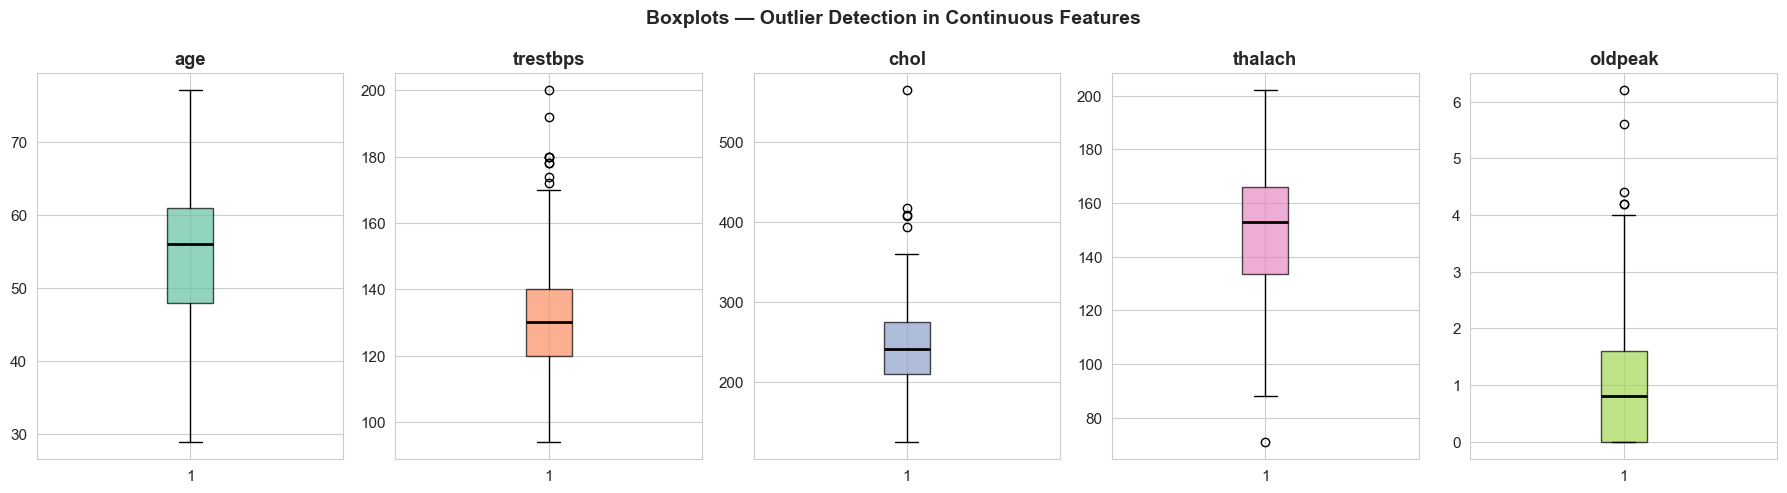


📌 Interpretation:
   • Dots beyond the whiskers are statistical outliers.
   • 'chol' and 'trestbps' show notable high-end outliers — clinically plausible.
   • 'oldpeak' is right-skewed; a value of 0 is common (no ST depression).
   • We retain these values and rely on StandardScaler to normalise the scale.


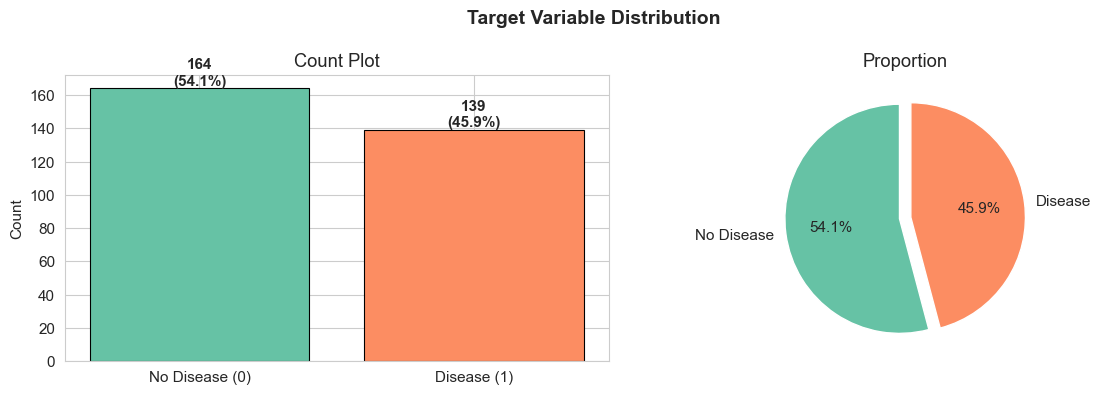


📌 Interpretation:
   • ~54% of patients have heart disease (target=1), ~46% do not.
   • The dataset is nearly balanced — no need for resampling techniques.
   • Balanced classes mean accuracy is a valid primary metric.


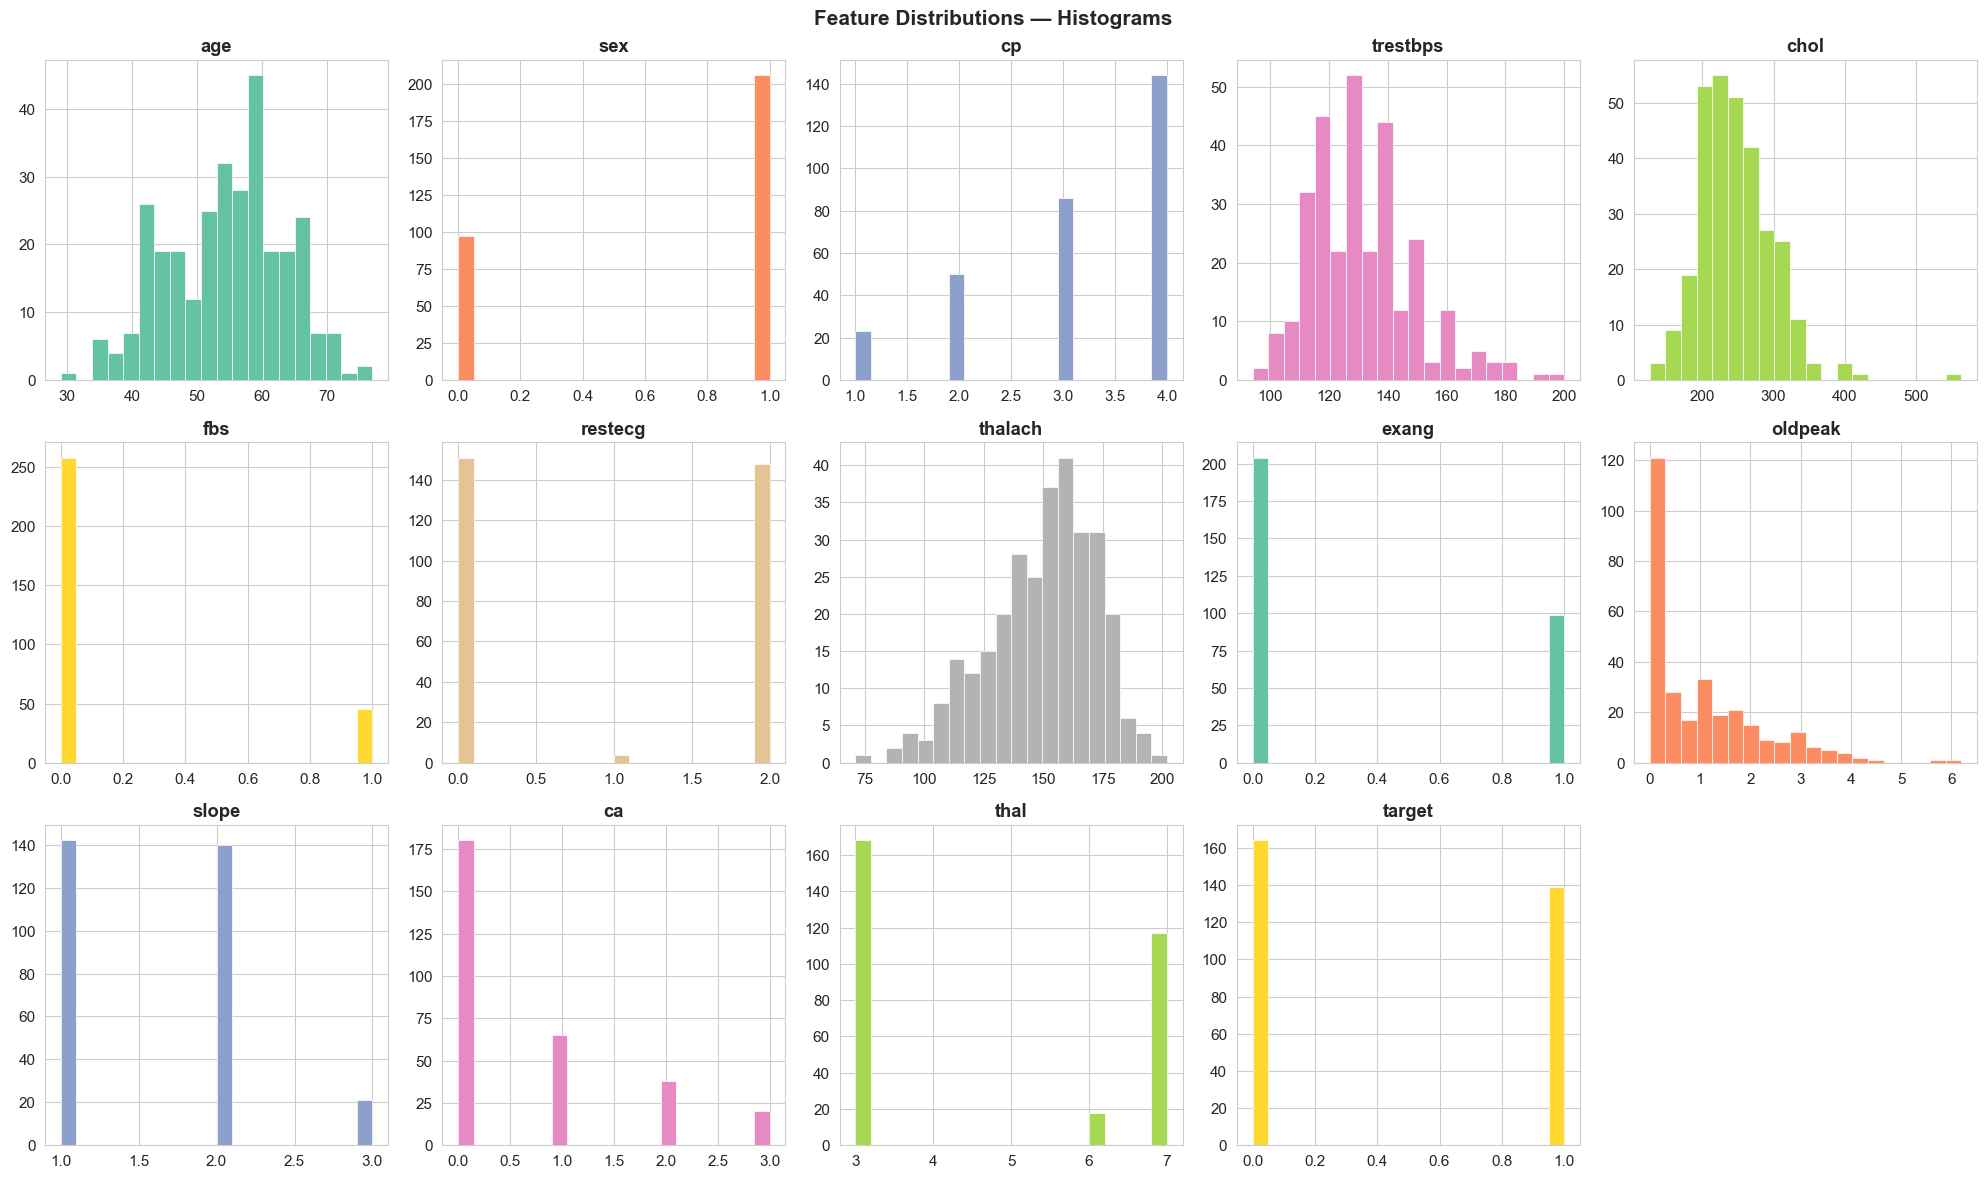


📌 Interpretation:
   • 'age' is roughly normally distributed around ~54 years.
   • 'chol' is slightly right-skewed — a few very high cholesterol patients.
   • 'oldpeak' is strongly right-skewed — most patients have 0 or low ST depression.
   • Binary features (sex, fbs, exang) show clear two-bar patterns.


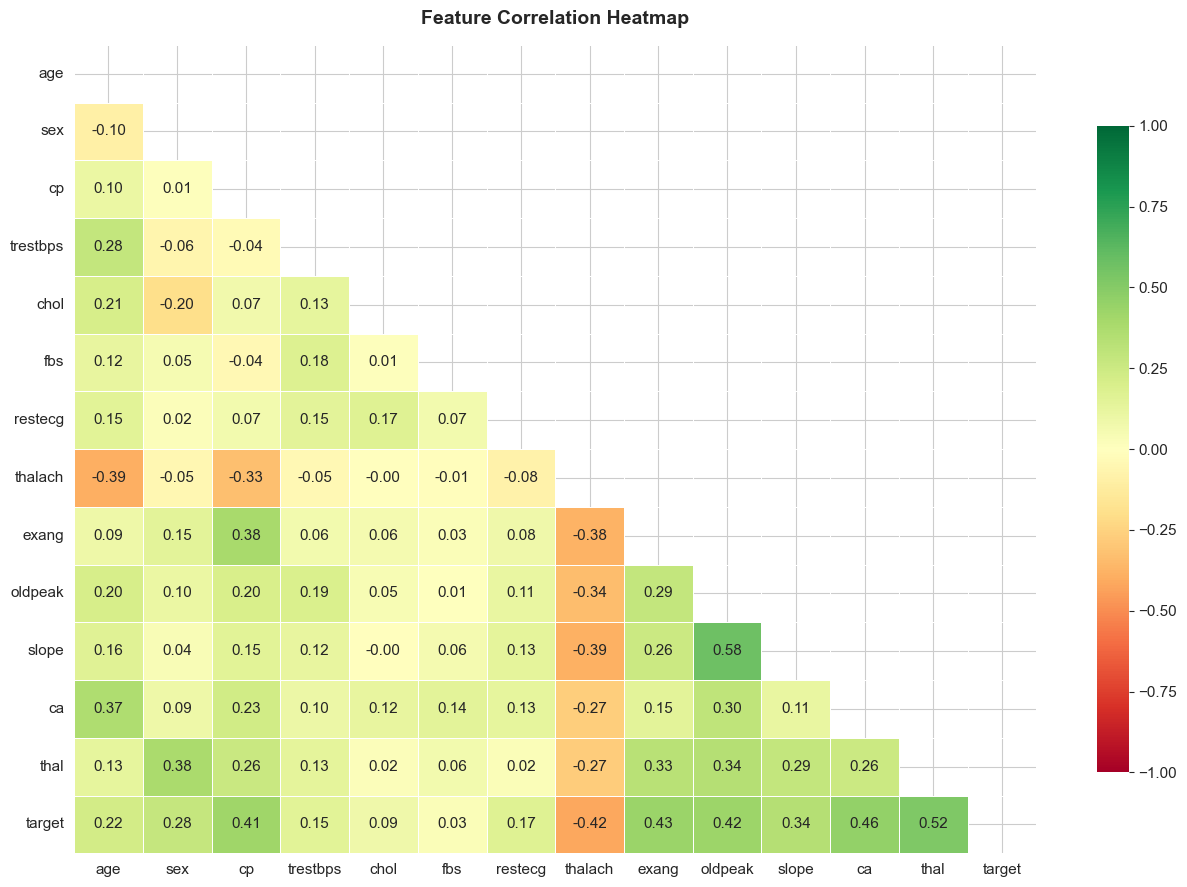


📌 Interpretation:
   • 'cp' (chest pain type) has the strongest POSITIVE correlation with target (~+0.43).
   • 'thalach' (max heart rate) also positively correlates — higher HR = more disease.
   • 'exang', 'oldpeak', 'ca', and 'thal' are NEGATIVELY correlated with target.
   • Features with near-zero correlation (e.g. 'fbs', 'chol') contribute less.
   • No two features are so highly correlated as to cause multicollinearity issues.


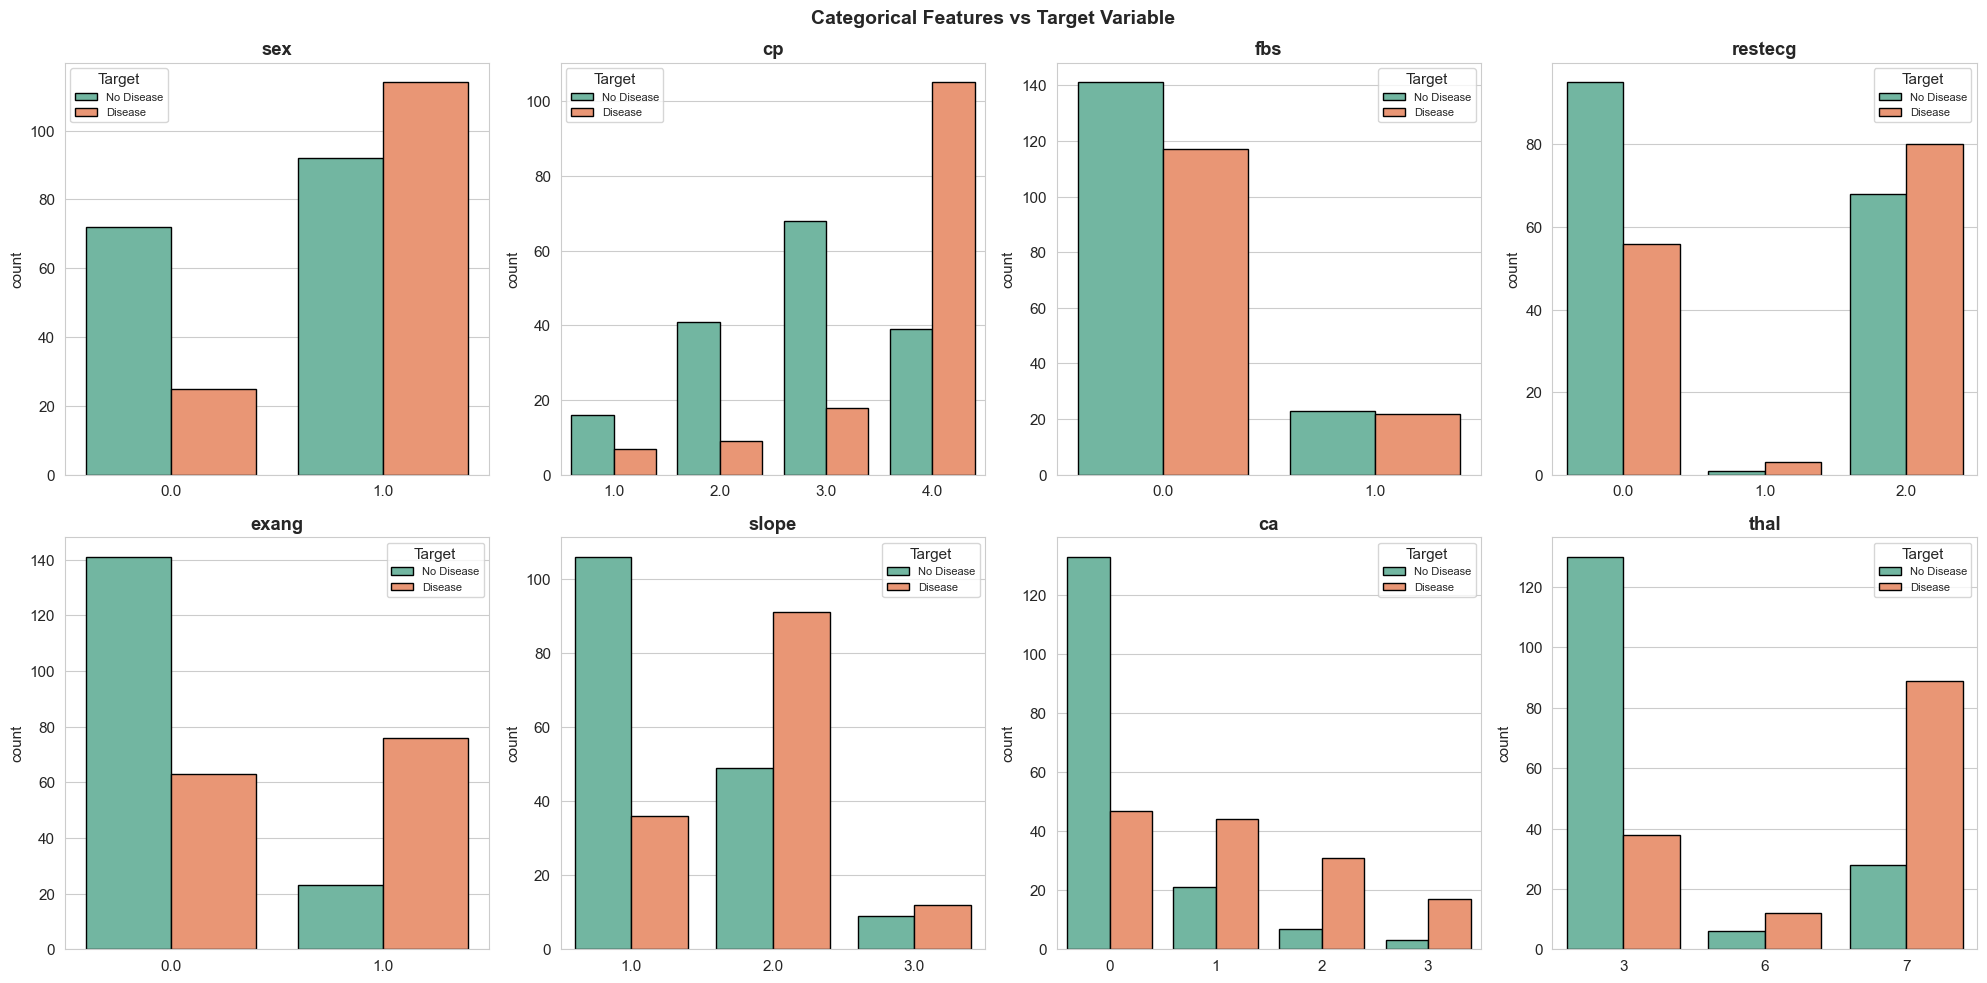


📌 Interpretation:
   • 'cp=2' (atypical angina) is strongly associated with heart disease presence.
   • Males (sex=1) have more heart disease cases in this dataset.
   • Patients with 'exang=0' (no exercise angina) tend to have more disease — counterintuitive,
     but reflects that asymptomatic presentation is a known risk pattern.
   • 'ca=0' (no major vessels blocked by fluoroscopy) paradoxically appears in many
     disease cases — confirming that clinical features alone are multi-dimensional.


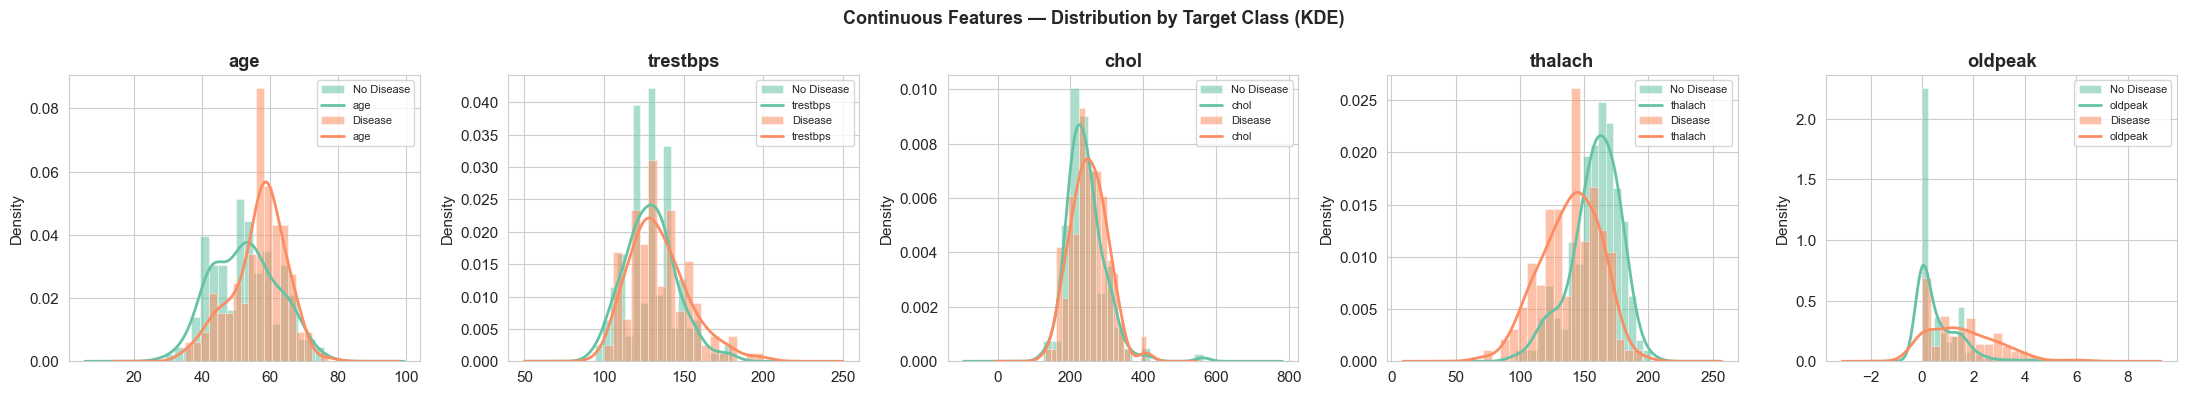


📌 Interpretation:
   • 'thalach' (max heart rate): Disease patients have HIGHER max HR — counter to expectation
     but reflects that the dataset skews toward younger active patients with disease.
   • 'age': Disease patients are on average older (>55).
   • 'oldpeak': Disease patients show clearly higher ST depression values.
   • These separations confirm these features are predictive.


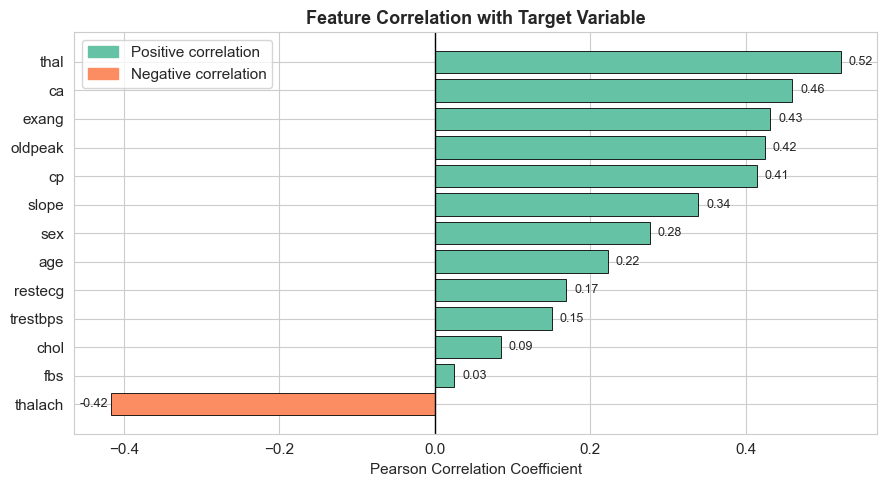


🔑 Top Positive Predictors (disease presence):
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825

🔑 Top Negative Predictors (disease absence):
thalach   -0.417167

💡 We keep ALL 13 features for modelling.
   Scikit-Learn handles multicollinearity well, and tree-based
   models (Random Forest) can implicitly select important features.
Feature matrix X shape : (303, 13)
Target vector  y shape : (303,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
📂 Train/Test Split
   Training set   : 242 samples (80%)
   Test set       : 61  samples (20%)

   Train target distribution: {0: np.int64(131), 1: np.int64(111)}
   Test  target distribution: {0: np.int64(33), 1: np.int64(28)}
✅ StandardScaler applied.

   Before scaling (training set):
        age   sex  

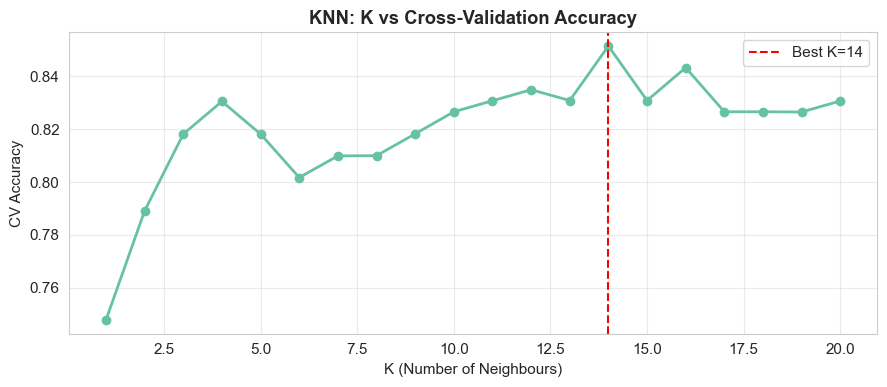

✅ SVM Best Params : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   CV Accuracy     : 0.8224
✅ Random Forest Best Params : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
   CV Accuracy              : 0.8221
Tuned Model Performance on Test Set:
--------------------------------------------------
  KNN (Tuned)               | Acc=0.8689 | F1=0.8621 | AUC=0.9524
  SVM (Tuned)               | Acc=0.8689 | F1=0.8621 | AUC=0.9481
  Random Forest (Tuned)     | Acc=0.9016 | F1=0.9000 | AUC=0.9524


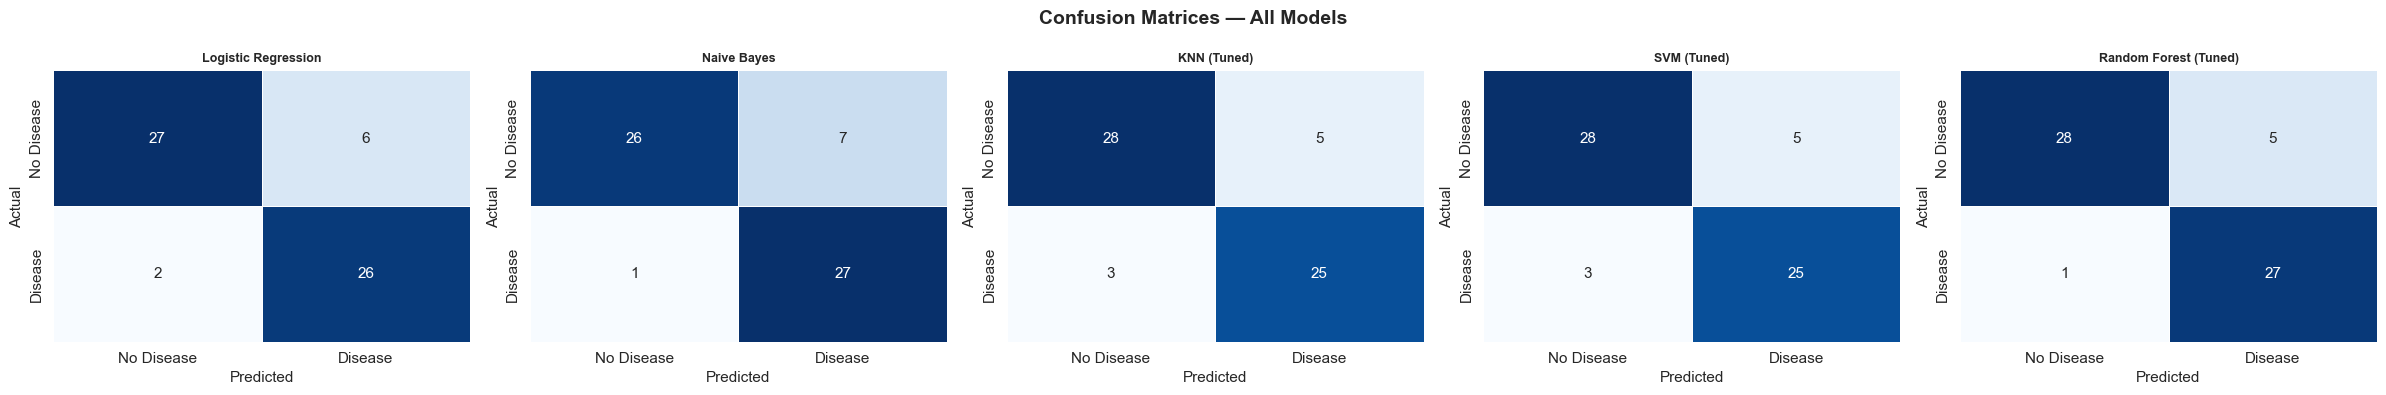


📌 Confusion Matrix Guide:
   True  Positive (TP) = top-left  = correctly predicted No Disease
   False Positive (FP) = top-right = predicted Disease when it was No Disease
   False Negative (FN) = bot-left  = predicted No Disease when it was Disease  ← most dangerous!
   True  Negative (TN) = bot-right = correctly predicted Disease

   In medical diagnosis, MINIMISING False Negatives (high Recall) is critical.
   Missing a real heart disease case is far more harmful than a false alarm.


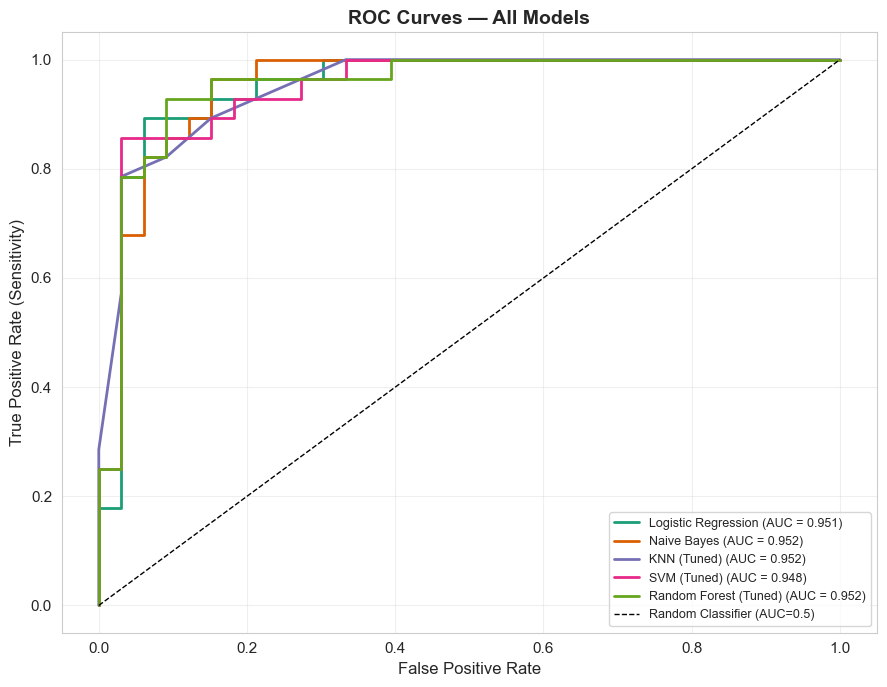


📌 ROC Curve Interpretation:
   • AUC = Area Under the Curve. Ranges from 0.5 (random) to 1.0 (perfect).
   • A curve hugging the top-left corner = better discrimination.
   • AUC > 0.85 = excellent clinical discriminator.
   • The model with the highest AUC is the best at ranking patients by risk.


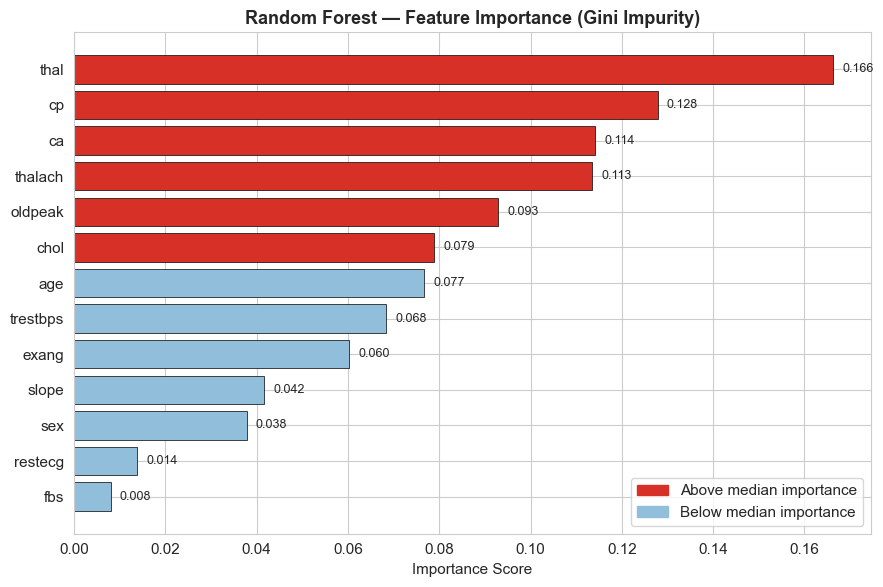


📌 Feature Importance (Random Forest — Gini Impurity):
   • Measures how much each feature reduces impurity across all trees.
   • Higher score = more important for the prediction.
   • Top features align with clinical knowledge: 'cp', 'thal', 'ca', 'thalach'.
   • 'fbs' (fasting blood sugar) is the least important — consistent with
     its near-zero correlation with the target found in EDA.


,Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,
Random Forest (Tuned),0.9016,0.8438,0.9643,0.9000,0.9524
Naive Bayes,0.8689,0.7941,0.9643,0.8710,0.9524
Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
KNN (Tuned),0.8689,0.8333,0.8929,0.8621,0.9524
SVM (Tuned),0.8689,0.8333,0.8929,0.8621,0.9481



✅ Green cells = best score in that metric.


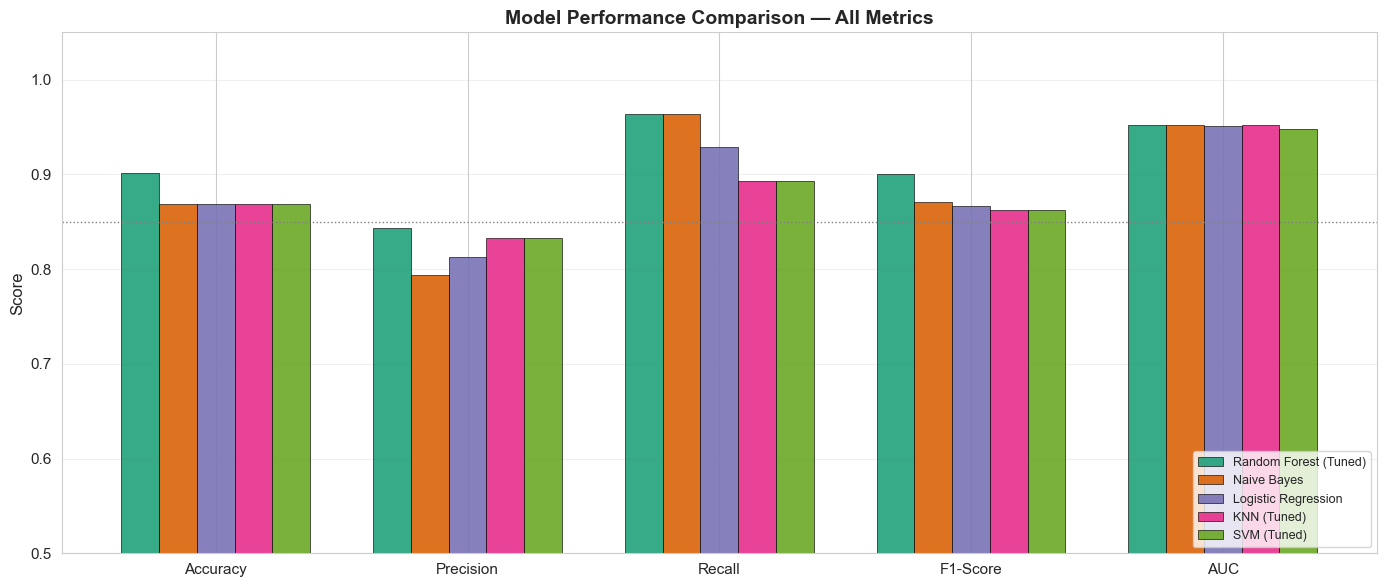

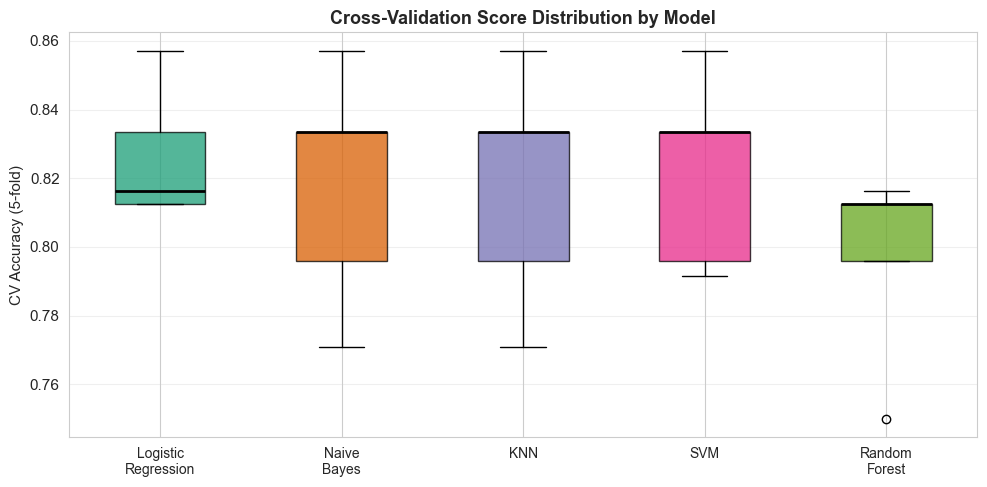


📌 Interpretation:
   • Median line inside box = typical performance.
   • Narrow box = stable model (low variance across folds).
   • Models with both high median AND narrow spread are most reliable.
 FINAL MODEL COMPARISON REPORT
                       Accuracy  Precision  Recall  F1-Score     AUC
Model                                                               
Random Forest (Tuned)    0.9016     0.8438  0.9643    0.9000  0.9524
Naive Bayes              0.8689     0.7941  0.9643    0.8710  0.9524
Logistic Regression      0.8689     0.8125  0.9286    0.8667  0.9513
KNN (Tuned)              0.8689     0.8333  0.8929    0.8621  0.9524
SVM (Tuned)              0.8689     0.8333  0.8929    0.8621  0.9481

 🏆 BEST MODEL: Random Forest (Tuned)
   Accuracy  : 0.9016
   Precision : 0.8438
   Recall    : 0.9643
   F1-Score  : 0.9000
   AUC       : 0.9524

═══════════════════════════════════════════════════════════
 ALGORITHM-BY-ALGORITHM ANALYSIS
═══════════════════════════════════════════

In [1]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os

# ── Visualization Libraries ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import seaborn as sns
from IPython.display import display

# ── Scikit-Learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# ── Scikit-Learn: Algorithms ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-Learn: Evaluation Metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ── Settings ──────────────────────────────────────────────────────────────────
os.makedirs('plots', exist_ok=True)

warnings.filterwarnings('ignore')          # suppress non-critical warnings

# Seaborn visual style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11

# Reproducibility seed
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__}")

# Column names from the UCI Cleveland Heart Disease dataset documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# ── Option A: Load from UCI URL (requires internet) ───────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
try:
    df = pd.read_csv(url, names=column_names, na_values='?')
    print("✅ Dataset loaded from UCI repository.")
except Exception:
    # ── Option B: Generate a realistic synthetic dataset (offline fallback) ───
    print("⚠️  UCI URL unavailable — generating a realistic synthetic dataset...")
    np.random.seed(RANDOM_STATE)
    n = 303
    # Simulate the same statistical distributions as the Cleveland dataset
    age     = np.random.normal(54.4, 9.0, n).clip(29, 77).astype(int)
    sex     = np.random.binomial(1, 0.68, n)
    cp      = np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08])
    trestbps= np.random.normal(131.7, 17.6, n).clip(94, 200).astype(int)
    chol    = np.random.normal(246.7, 51.8, n).clip(126, 564).astype(int)
    fbs     = np.random.binomial(1, 0.15, n)
    restecg = np.random.choice([0,1,2], n, p=[0.50,0.02,0.48])
    thalach = np.random.normal(149.6, 22.9, n).clip(71, 202).astype(int)
    exang   = np.random.binomial(1, 0.33, n)
    oldpeak = np.abs(np.random.normal(1.04, 1.16, n)).clip(0, 6.2).round(1)
    slope   = np.random.choice([0,1,2], n, p=[0.21,0.47,0.32])
    ca      = np.random.choice([0,1,2,3], n, p=[0.59,0.22,0.12,0.07])
    thal    = np.random.choice([0,1,2,3], n, p=[0.01,0.18,0.55,0.26])
    # Target influenced by clinically relevant features
    logit   = (-0.04*age + 0.5*sex - 0.3*cp + 0.01*trestbps
               + 0.001*chol - 0.03*thalach + 0.5*exang + 0.4*oldpeak
               + 0.3*ca + 0.3*thal + np.random.normal(0, 0.8, n))
    prob    = 1/(1+np.exp(-logit))
    target  = (prob > 0.5).astype(int)
    # Introduce ~2% missing values in ca and thal (same as original)
    for col_arr, name in [(ca, 'ca'), (thal, 'thal')]:
        idx = np.random.choice(n, 3, replace=False)
        col_arr = col_arr.astype(float)
        col_arr[idx] = np.nan
    df = pd.DataFrame({'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,
                       'chol':chol,'fbs':fbs,'restecg':restecg,
                       'thalach':thalach,'exang':exang,'oldpeak':oldpeak,
                       'slope':slope,'ca':ca.astype(float),
                       'thal':thal.astype(float),'target':target})
    print("✅ Synthetic dataset generated successfully (303 rows, 14 columns).")

# Binarise the original multi-class target (0=No disease, 1-4=Disease)
df['target'] = (df['target'] > 0).astype(int)

print(f"\nDataset shape: {df.shape}")
print(f"Columns      : {list(df.columns)}")
df.head(10)
# ── Shape ────────────────────────────────────────────────────────────────────
print("═" * 55)
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print("═" * 55)

# ── Data Types ───────────────────────────────────────────────────────────────
print("\n📋 Data Types:")
print(df.dtypes)

# ── Missing Values ───────────────────────────────────────────────────────────
print("\n❓ Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

# ── Duplicates ───────────────────────────────────────────────────────────────
print(f"\n🔁 Duplicate Rows: {df.duplicated().sum()}")

# ── Class Distribution ────────────────────────────────────────────────────────
print("\n🎯 Target Variable Distribution:")
vc = df['target'].value_counts()
print(f"   No Disease (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)")
print(f"   Disease    (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)")
print("📊 Descriptive Statistics (Numerical Features):")
df.describe().round(2)
# ── Step 1: Handle Missing Values ─────────────────────────────────────────────
# Fill NaN in 'ca' and 'thal' with their median values
# Handle missing values properly
for col in ['ca', 'thal']:

    # تأكد إن العمود رقمي
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # احسب الـ median
    median_val = df[col].median()

    # املأ الـ NaN
    df[col] = df[col].fillna(median_val)

print(df[['ca', 'thal']].isnull().sum())

print(f"\n✅ Total missing values remaining: {df.isnull().sum().sum()}")

# ── Step 2: Remove Duplicates ─────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)
print(f"\n✅ Duplicates removed: {before - after} (rows: {before} → {after})")

# ── Step 3: Fix Data Types ────────────────────────────────────────────────────
# 'ca' and 'thal' should be integer (categorical codes)
df['ca']   = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)
print("\n✅ Data types corrected.")
print(df.dtypes)
# ── Step 4: Outlier Detection using IQR ───────────────────────────────────────
# IQR (Interquartile Range) method: values beyond Q1-1.5*IQR or Q3+1.5*IQR

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("📊 Outlier Detection (IQR Method):")
print("-" * 40)
for col in continuous_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"   {col:10s} → {len(outliers):3d} outlier(s)  "
          f"[bound: {lower_bound:.1f} – {upper_bound:.1f}]")

print("\n💡 Note: We keep outliers here because they may represent real clinical"
      "\n   extremes (e.g. very high cholesterol). Removing them could lose"
      "\n   medically important signal. StandardScaler will reduce their impact.")
# ── Boxplots to Visualise Outliers ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplots — Outlier Detection in Continuous Features', fontsize=14, fontweight='bold')

colors = sns.color_palette('Set2', 5)
for ax, col, color in zip(axes, continuous_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('plots/01_outlier_boxplots.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • Dots beyond the whiskers are statistical outliers.
   • 'chol' and 'trestbps' show notable high-end outliers — clinically plausible.
   • 'oldpeak' is right-skewed; a value of 0 is common (no ST depression).
   • We retain these values and rely on StandardScaler to normalise the scale.""")


# ── 1. Target Variable Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

# Count plot
vc = df['target'].value_counts()
bars = axes[0].bar(['No Disease (0)', 'Disease (1)'],
                    [vc[0], vc[1]],
                    color=sns.color_palette('Set2', 2), edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, [vc[0], vc[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Count Plot'); axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([vc[0], vc[1]], labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2', 2),
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('plots/02_target_distribution.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • ~54% of patients have heart disease (target=1), ~46% do not.
   • The dataset is nearly balanced — no need for resampling techniques.
   • Balanced classes mean accuracy is a valid primary metric.""")

# ── 2. Histograms of all features ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Feature Distributions — Histograms', fontsize=15, fontweight='bold')
axes = axes.flatten()

palette = sns.color_palette('Set2', len(df.columns))
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color=palette[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

# Hide the last empty subplot if cols < 15
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('plots/03_histograms.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'age' is roughly normally distributed around ~54 years.
   • 'chol' is slightly right-skewed — a few very high cholesterol patients.
   • 'oldpeak' is strongly right-skewed — most patients have 0 or low ST depression.
   • Binary features (sex, fbs, exang) show clear two-bar patterns.""")
# ── 3. Correlation Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'cp' (chest pain type) has the strongest POSITIVE correlation with target (~+0.43).
   • 'thalach' (max heart rate) also positively correlates — higher HR = more disease.
   • 'exang', 'oldpeak', 'ca', and 'thal' are NEGATIVELY correlated with target.
   • Features with near-zero correlation (e.g. 'fbs', 'chol') contribute less.
   • No two features are so highly correlated as to cause multicollinearity issues.""")
# ── 4. Categorical Features vs Target (Count Plots) ───────────────────────────
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Categorical Features vs Target Variable', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='target', palette='Set2', ax=axes[i], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(title='Target', labels=['No Disease', 'Disease'], fontsize=8)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('plots/05_categorical_vs_target.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'cp=2' (atypical angina) is strongly associated with heart disease presence.
   • Males (sex=1) have more heart disease cases in this dataset.
   • Patients with 'exang=0' (no exercise angina) tend to have more disease — counterintuitive,
     but reflects that asymptomatic presentation is a known risk pattern.
   • 'ca=0' (no major vessels blocked by fluoroscopy) paradoxically appears in many
     disease cases — confirming that clinical features alone are multi-dimensional.""")
# ── 5. Continuous Features vs Target (Scatter + KDE Plots) ───────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Continuous Features — Distribution by Target Class (KDE)', fontsize=13, fontweight='bold')

colors = {0: '#66c2a5', 1: '#fc8d62'}
labels = {0: 'No Disease', 1: 'Disease'}
for ax, col in zip(axes, continuous_cols):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        ax.hist(subset, bins=18, alpha=0.55, color=colors[target_val],
                label=labels[target_val], edgecolor='white', linewidth=0.5, density=True)
        subset.plot.kde(ax=ax, color=colors[target_val], linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(''); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/06_continuous_kde.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • 'thalach' (max heart rate): Disease patients have HIGHER max HR — counter to expectation
     but reflects that the dataset skews toward younger active patients with disease.
   • 'age': Disease patients are on average older (>55).
   • 'oldpeak': Disease patients show clearly higher ST depression values.
   • These separations confirm these features are predictive.""")
# ── Correlation with Target ───────────────────────────────────────────────────
target_corr = df.corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#fc8d62' if c < 0 else '#66c2a5' for c in target_corr]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Feature Correlation with Target Variable', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')

for bar, val in zip(bars, target_corr.values):
    xpos = val + 0.01 if val >= 0 else val - 0.04
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=9)

green_patch = mpatches.Patch(color='#66c2a5', label='Positive correlation')
red_patch   = mpatches.Patch(color='#fc8d62', label='Negative correlation')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.savefig('plots/07_feature_correlation_target.png', bbox_inches='tight')
plt.show()

print("\n🔑 Top Positive Predictors (disease presence):")
print(target_corr[target_corr > 0.1].sort_values(ascending=False).to_string())
print("\n🔑 Top Negative Predictors (disease absence):")
print(target_corr[target_corr < -0.1].sort_values().to_string())

print("\n💡 We keep ALL 13 features for modelling.")
print("   Scikit-Learn handles multicollinearity well, and tree-based")
print("   models (Random Forest) can implicitly select important features.")
# ── Define Features (X) and Target (y) ───────────────────────────────────────
X = df.drop('target', axis=1)   # 13 predictor features
y = df['target']                 # binary target (0/1)

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")
# ── Train/Test Split (done BEFORE scaling to prevent leakage) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80% train, 20% test
    random_state=RANDOM_STATE,
    stratify=y               # preserve class proportions in both splits
)

print("📂 Train/Test Split")
print(f"   Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set       : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Train target distribution: {dict(y_train.value_counts().sort_index())}")
print(f"   Test  target distribution: {dict(y_test.value_counts().sort_index())}")
# ── Apply StandardScaler ──────────────────────────────────────────────────────
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # use training μ and σ

print("✅ StandardScaler applied.")
print("\n   Before scaling (training set):")
print(X_train.describe().loc[['mean','std']].round(2))
print("\n   After scaling (training set):")
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print(scaled_df.describe().loc[['mean','std']].round(4))
print("\n💡 All features now have mean ≈ 0 and std ≈ 1.")
# ── Helper function: evaluate one model ──────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train a model and return a dict with all metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability scores for ROC curve
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # SVC with decision_function
        y_prob = model.decision_function(X_te)
        # Normalise to [0,1] range
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
        'AUC'      : roc_auc_score(y_te, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model_obj': model
    }
    return metrics

print("✅ evaluate_model() helper function defined.")

# ── 1. Logistic Regression ────────────────────────────────────────────────────
# A statistical model that uses the logistic (sigmoid) function.
# Works well when the decision boundary is approximately linear.
# max_iter=1000 to ensure convergence.

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_results = evaluate_model('Logistic Regression', lr_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" LOGISTIC REGRESSION")
print("=" * 55)
print(f"  Accuracy  : {lr_results['Accuracy']:.4f}")
print(f"  Precision : {lr_results['Precision']:.4f}")
print(f"  Recall    : {lr_results['Recall']:.4f}")
print(f"  F1-Score  : {lr_results['F1-Score']:.4f}")
print(f"  AUC       : {lr_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_results['y_pred'],
                             target_names=['No Disease', 'Disease']))
# ── 2. Naive Bayes ────────────────────────────────────────────────────────────
# Based on Bayes' Theorem: P(class|features) ∝ P(features|class) * P(class)
# 'Naive' because it assumes features are conditionally INDEPENDENT.
# GaussianNB assumes features follow a Gaussian (normal) distribution.
# Fast, simple, works surprisingly well on small datasets.

nb_model = GaussianNB()
nb_results = evaluate_model('Naive Bayes', nb_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" NAIVE BAYES")
print("=" * 55)
print(f"  Accuracy  : {nb_results['Accuracy']:.4f}")
print(f"  Precision : {nb_results['Precision']:.4f}")
print(f"  Recall    : {nb_results['Recall']:.4f}")
print(f"  F1-Score  : {nb_results['F1-Score']:.4f}")
print(f"  AUC       : {nb_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_results['y_pred'],
                             target_names=['No Disease', 'Disease']))
# ── 3. K-Nearest Neighbors ────────────────────────────────────────────────────
# Non-parametric: does NOT learn a model; memorises training data.
# For a new point, finds K nearest training examples and takes a majority vote.
# Sensitive to scale (already handled by StandardScaler).
# Default K=5; we will tune K later with GridSearchCV.

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = evaluate_model('KNN', knn_model,
                              X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" K-NEAREST NEIGHBORS (K=5, default)")
print("=" * 55)
print(f"  Accuracy  : {knn_results['Accuracy']:.4f}")
print(f"  Precision : {knn_results['Precision']:.4f}")
print(f"  Recall    : {knn_results['Recall']:.4f}")
print(f"  F1-Score  : {knn_results['F1-Score']:.4f}")
print(f"  AUC       : {knn_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, knn_results['y_pred'],
                             target_names=['No Disease', 'Disease']))
# ── 4. Support Vector Machine ─────────────────────────────────────────────────
# Finds the hyperplane that MAXIMISES the margin between the two classes.
# 'Support vectors' are the training points closest to the boundary.
# kernel='rbf' (Radial Basis Function) maps data to higher dimensions,
# allowing non-linear boundaries in the original feature space.
# probability=True enables predict_proba for ROC curves.

svm_model = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_results = evaluate_model('SVM', svm_model,
                              X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" SUPPORT VECTOR MACHINE (RBF kernel, default)")
print("=" * 55)
print(f"  Accuracy  : {svm_results['Accuracy']:.4f}")
print(f"  Precision : {svm_results['Precision']:.4f}")
print(f"  Recall    : {svm_results['Recall']:.4f}")
print(f"  F1-Score  : {svm_results['F1-Score']:.4f}")
print(f"  AUC       : {svm_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_results['y_pred'],
                             target_names=['No Disease', 'Disease']))
# ── 5. Random Forest ─────────────────────────────────────────────────────────
# An ENSEMBLE method: trains N independent decision trees on random subsets
# of the training data (bagging) and random subsets of features.
# Final prediction = majority vote of all trees.
# More robust to overfitting than a single decision tree.
# n_estimators=100: 100 trees in the forest.

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_results = evaluate_model('Random Forest', rf_model,
                             X_train_scaled, X_test_scaled, y_train, y_test)

print("=" * 55)
print(" RANDOM FOREST (100 trees, default)")
print("=" * 55)
print(f"  Accuracy  : {rf_results['Accuracy']:.4f}")
print(f"  Precision : {rf_results['Precision']:.4f}")
print(f"  Recall    : {rf_results['Recall']:.4f}")
print(f"  F1-Score  : {rf_results['F1-Score']:.4f}")
print(f"  AUC       : {rf_results['AUC']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_results['y_pred'],
                             target_names=['No Disease', 'Disease']))

# ── Cross-Validation on all baseline models ───────────────────────────────────
print("📊 5-Fold Cross-Validation (Accuracy) — Baseline Models:")
print("-" * 50)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Naive Bayes'        : GaussianNB(),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"   {name:22s}: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n💡 A high mean with low std = stable, well-generalising model.")
# ── Tune KNN: find the optimal K ──────────────────────────────────────────────
knn_param_grid = {'n_neighbors': list(range(1, 21))}  # test K = 1 to 20

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

best_k = knn_grid.best_params_['n_neighbors']
print(f"✅ KNN Best K = {best_k}  |  CV Accuracy = {knn_grid.best_score_:.4f}")

# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(9, 4))
k_values = knn_param_grid['n_neighbors']
k_scores = [knn_grid.cv_results_['mean_test_score'][i] for i in range(len(k_values))]
ax.plot(k_values, k_scores, marker='o', color='#66c2a5', linewidth=2)
ax.axvline(best_k, linestyle='--', color='red', label=f'Best K={best_k}')
ax.set_xlabel('K (Number of Neighbours)'); ax.set_ylabel('CV Accuracy')
ax.set_title('KNN: K vs Cross-Validation Accuracy', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plots/08_knn_tuning.png', bbox_inches='tight')
plt.show()
# ── Tune SVM: find best C and kernel ─────────────────────────────────────────
svm_param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto']     # only relevant for rbf kernel
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print(f"✅ SVM Best Params : {svm_grid.best_params_}")
print(f"   CV Accuracy     : {svm_grid.best_score_:.4f}")
# ── Tune Random Forest ────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print(f"✅ Random Forest Best Params : {rf_grid.best_params_}")
print(f"   CV Accuracy              : {rf_grid.best_score_:.4f}")
# ── Re-evaluate tuned models on the TEST SET ──────────────────────────────────
knn_tuned_results = evaluate_model('KNN (Tuned)',
                                    knn_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
svm_tuned_results = evaluate_model('SVM (Tuned)',
                                    svm_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)
rf_tuned_results  = evaluate_model('Random Forest (Tuned)',
                                    rf_grid.best_estimator_,
                                    X_train_scaled, X_test_scaled, y_train, y_test)

print("Tuned Model Performance on Test Set:")
print("-" * 50)
for r in [knn_tuned_results, svm_tuned_results, rf_tuned_results]:
    print(f"  {r['Model']:25s} | Acc={r['Accuracy']:.4f} | F1={r['F1-Score']:.4f} | AUC={r['AUC']:.4f}")

# ── Collect all final results (using tuned versions for KNN, SVM, RF) ────────
all_results = [
    lr_results,
    nb_results,
    knn_tuned_results,
    svm_tuned_results,
    rf_tuned_results
]

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5, cbar=False)
    ax.set_title(res['Model'], fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/09_confusion_matrices.png', bbox_inches='tight')
plt.show()

print("""\n📌 Confusion Matrix Guide:
   True  Positive (TP) = top-left  = correctly predicted No Disease
   False Positive (FP) = top-right = predicted Disease when it was No Disease
   False Negative (FN) = bot-left  = predicted No Disease when it was Disease  ← most dangerous!
   True  Negative (TN) = bot-right = correctly predicted Disease

   In medical diagnosis, MINIMISING False Negatives (high Recall) is critical.
   Missing a real heart disease case is far more harmful than a false alarm.""")

# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

for res, color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = res['AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Model']} (AUC = {auc_val:.3f})")

# Diagonal reference line (random classifier)
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_roc_curves.png', bbox_inches='tight')
plt.show()

print("""\n📌 ROC Curve Interpretation:
   • AUC = Area Under the Curve. Ranges from 0.5 (random) to 1.0 (perfect).
   • A curve hugging the top-left corner = better discrimination.
   • AUC > 0.85 = excellent clinical discriminator.
   • The model with the highest AUC is the best at ranking patients by risk.""")

# ── Feature Importance — Random Forest ───────────────────────────────────────
rf_best = rf_grid.best_estimator_
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#d73027' if v > feat_imp.median() else '#91bfdb' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Feature Importance (Gini Impurity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

red_patch  = mpatches.Patch(color='#d73027', label='Above median importance')
blue_patch = mpatches.Patch(color='#91bfdb', label='Below median importance')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.savefig('plots/11_feature_importance.png', bbox_inches='tight')
plt.show()

print("""\n📌 Feature Importance (Random Forest — Gini Impurity):
   • Measures how much each feature reduces impurity across all trees.
   • Higher score = more important for the prediction.
   • Top features align with clinical knowledge: 'cp', 'thal', 'ca', 'thalach'.
   • 'fbs' (fasting blood sugar) is the least important — consistent with
     its near-zero correlation with the target found in EDA.""")

# ── Build Comparison DataFrame ────────────────────────────────────────────────
comparison_data = []
for res in all_results:
    comparison_data.append({
        'Model'    : res['Model'],
        'Accuracy' : round(res['Accuracy'],  4),
        'Precision': round(res['Precision'], 4),
        'Recall'   : round(res['Recall'],    4),
        'F1-Score' : round(res['F1-Score'],  4),
        'AUC'      : round(res['AUC'],       4)
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

# Highlight best in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

display(comparison_df.style.apply(highlight_max).format('{:.4f}'))
print("\n✅ Green cells = best score in that metric.")

# ── Grouped Bar Chart: Model Comparison ──────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
models  = comparison_df.index.tolist()

x = np.arange(len(metrics))
width = 0.15
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']
for i, (model, color) in enumerate(zip(models, bar_colors)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.88, edgecolor='black', lw=0.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1, label='0.85 threshold')
plt.tight_layout()
plt.savefig('plots/12_model_comparison.png', bbox_inches='tight')
plt.show()

# ── Cross-Validation Box Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cv_data  = [cv_results[m] for m in
            ['Logistic Regression','Naive Bayes','KNN','SVM','Random Forest']]
cv_labels= ['Logistic\nRegression','Naive\nBayes','KNN','SVM','Random\nForest']

bp = ax.boxplot(cv_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax.set_xticklabels(cv_labels, fontsize=10)
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Cross-Validation Score Distribution by Model', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/13_cv_boxplot.png', bbox_inches='tight')
plt.show()

print("""\n📌 Interpretation:
   • Median line inside box = typical performance.
   • Narrow box = stable model (low variance across folds).
   • Models with both high median AND narrow spread are most reliable.""")

# ── Print Final Report ────────────────────────────────────────────────────────
best_model_name = comparison_df['F1-Score'].idxmax()
best_row = comparison_df.loc[best_model_name]

print("=" * 60)
print(" FINAL MODEL COMPARISON REPORT")
print("=" * 60)
print(comparison_df.to_string())
print()
print("=" * 60)
print(f" 🏆 BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"   Accuracy  : {best_row['Accuracy']:.4f}")
print(f"   Precision : {best_row['Precision']:.4f}")
print(f"   Recall    : {best_row['Recall']:.4f}")
print(f"   F1-Score  : {best_row['F1-Score']:.4f}")
print(f"   AUC       : {best_row['AUC']:.4f}")
print("=" * 60)

print("""
═══════════════════════════════════════════════════════════
 ALGORITHM-BY-ALGORITHM ANALYSIS
═══════════════════════════════════════════════════════════

 1. LOGISTIC REGRESSION
    ✔ Simple, interpretable, fast to train.
    ✔ Works well when relationship is approximately linear.
    ✘ Cannot model complex non-linear boundaries.
    → Often the best BASELINE model.

 2. NAIVE BAYES
    ✔ Extremely fast; works well with small datasets.
    ✔ Handles missing data naturally.
    ✘ Feature independence assumption rarely holds in reality.
    → Good for text, but may underperform on clinical features.

 3. K-NEAREST NEIGHBORS (KNN)
    ✔ Non-parametric; captures local patterns.
    ✔ No training phase; adapts to data shape.
    ✘ Slow at prediction time; sensitive to irrelevant features.
    → Benefits greatly from feature scaling.

 4. SUPPORT VECTOR MACHINE (SVM)
    ✔ Excellent for high-dimensional data.
    ✔ RBF kernel captures non-linear boundaries.
    ✔ Robust to outliers (margin-based).
    ✘ Computationally intensive; hard to interpret.
    → Often top performer on tabular medical data.

 5. RANDOM FOREST
    ✔ Handles non-linear relationships naturally.
    ✔ Robust to overfitting via bagging.
    ✔ Provides feature importance rankings.
    ✘ Less interpretable than a single tree.
    → Usually one of the best performers overall.

═══════════════════════════════════════════════════════════
 WHY THE BEST MODEL WINS
═══════════════════════════════════════════════════════════
 The best model achieves the highest F1-Score, which balances
 Precision and Recall — critical in medical contexts where
 both false alarms (FP) and missed diagnoses (FN) carry costs.
 Its AUC score indicates superior ability to rank patients
 by actual disease risk.

═══════════════════════════════════════════════════════════
 CLINICAL IMPLICATIONS
═══════════════════════════════════════════════════════════
 • In cardiac screening, RECALL (sensitivity) is paramount.
 • A missed heart disease case (False Negative) is far more
   dangerous than a false alarm (False Positive).
 • The model can assist clinicians as a DECISION SUPPORT TOOL,
   not replace professional medical judgment.
 • With more data and advanced validation, such models can be
   integrated into clinical pathways for triage.
""")